# Расчет локальных оптимумов и рельефа оптимальности

In [1]:
import geopandas as gpd
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from genesis.metrics import *
from genesis.core import BestPointsBase, StateBase
from genesis.states import FirstArrivalUnitState
from genesis.utils import Progressbar, timing
from genesis.best_points import NodeMetric

In [2]:
# Загрузка графа, полигона границ и зданий
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

print(G.number_of_nodes(), G.number_of_edges())

5514 12199


In [3]:
Gs = ox.simplify_graph(G)
print(Gs.number_of_nodes(), Gs.number_of_edges())

1941 5261


## Расчет

Рассчитываем локальные оптимумы и рельеф для каждого из них

### Только оптимумы

Для теста

In [5]:
# class NodeMetric(BestPointsBase):
#     '''
#     Расчет метрики для конкретного узла графа.
    
#     ## Важно
#     Применяется строго к графам!
#     '''
#     def __init__(self, state_function: StateBase,
#                  metric_function: MetricBase,
#                  appr_val = 0.95,
#                  err_val=None,
#                  **kwargs) -> None:

#         self.appr_val = appr_val
#         self.err_val = err_val
#         super().__init__(state_function, metric_function, **kwargs)

#     def __call__(self, env:nx.MultiDiGraph, node:int, area=None, **kwargs):

#         # Если маска приемлемых узлов графа не передана,
#         # то приемлемое количество узлов считается от количества узлов в графе
#         # Иначе - от количества True в маске
#         if area is None:
#             appr_nodes_count = int(env.number_of_nodes() * self.appr_val)
#         else:
#             appr_nodes_count = int(sum(area) * self.appr_val)
#         # # Приемлемое количество узлов считается от количества узлов в графе
#         # appr_nodes_count = int(env.number_of_nodes() * self.appr_val)

#         # Собственно расчет
#         times, _ = self.state_function(env=env, points=[node], area=area, **kwargs)
#         if len(times)>=appr_nodes_count:
#             cur_val = self.metric_function(times, **kwargs)
#         else:
#             cur_val = self.err_val
#         return cur_val


class AllBestNodesFull(BestPointsBase):
    '''
    Расчет всех оптимумов
    '''
    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 appr_val: float = 0.95,
                 node_calc_end_function:callable=None,
                 **kwargs) -> None:
        self.appr_val = appr_val
        self.node_calc_end_function = node_calc_end_function
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self, env:nx.MultiDiGraph,
                 area:pd.Series=None,
                 nodes_list:set=None,
                 **kwargs):

        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError('Тип данных аргумента `env` должен быть nx.MultiDiGraph')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

        # Если списка узлов изначально не передано, рассматриваются все узлы графа
        if nodes_list is None:
            nodes_list = env.nodes()

        best_metric = None
        best_nodes_list = []
        optimums_list = []
        optimums_metrics = []

        # Функция определения метрики лучшего узла
        node_metric_func = NodeMetric(self.state_function, self.metric_function, self.appr_val, err_val=None)


        for node in nodes_list:
            node_metric = node_metric_func(env=env, node=node, area=area)

            # проверка на корректность охвата графа
            if node_metric:

                # если лучшая метрика еще не указана, присваиваем текущее значение
                if best_metric is None:
                    best_metric = node_metric
                    best_nodes_list = [node]

                # проверяем лучше ли метрика среды для текущего узла, чем лучшая до этого
                else:
                    # if best_metric > node_metric:
                    if self.metric_function.compare(best_metric, node_metric) == node_metric:
                        if best_metric == node_metric:
                            best_nodes_list.append(node)
                        else:
                            best_nodes_list = [node]

                        best_metric = node_metric

                # Расчет метрик соседних узлов
                add_flag = True
                for neighbor in env[node]:

                    neighbor_metric = node_metric_func(env=env, node=neighbor, area=area)

                    # проверка на корректность охвата графа
                    if neighbor_metric:

                        # если метрика соседнего узла меньше чем метрика текущего узла
                        if self.metric_function.compare(node_metric, neighbor_metric) == neighbor_metric:
                            add_flag = False
                            break
                if add_flag:
                    optimums_list.append(node)
                    optimums_metrics.append(node_metric)

                        

            # выполняем функцию завершения расчета для узла
            if self.node_calc_end_function:
                self.node_calc_end_function()

        return list(best_nodes_list), best_metric, optimums_list, optimums_metrics
    


print('Упрощенный граф, метрика mean')
pb = Progressbar(Gs.number_of_nodes(), bins=40)
abnf = timing(AllBestNodesFull(FirstArrivalUnitState(), ArrivalTime(), node_calc_end_function=pb))
best_nodes_list, best_metric, optimums_list, optimums_metrics = abnf(
    env=Gs,
)
for o,m in zip(optimums_list, optimums_metrics):
    print(o, m)

print('='*80)
print('Упрощенный граф, метрика max')
pb = Progressbar(Gs.number_of_nodes(), bins=40)
abnf = timing(AllBestNodesFull(FirstArrivalUnitState(), ArrivalTime(np.max), node_calc_end_function=pb))
best_nodes_list, best_metric, optimums_list, optimums_metrics = abnf(
    env=Gs,
)
for o,m in zip(optimums_list, optimums_metrics):
    print(o, m)

Упрощенный граф, метрика mean
|########################################| 100.0%
ВРЕМЯ: 136.52 сек
426923808 7.789429840494647
426923835 7.800295752971576
426923837 7.6493893689184205
1297042721 7.794774674234035
1550153892 7.72729466725729
1705509859 8.717205542709488
2546773068 8.782454585308233
2586140869 11.87924487021041
4329379210 10.402021424437061
4329379225 10.403819336581764
4702619724 12.380565249999998
Упрощенный граф, метрика max
|########################################| 100.0%
ВРЕМЯ: 129.09 сек
2034401823 18.917574142857138
2034402008 19.70348657142857
4116049991 18.036191714285714
4329379210 20.83746514285714
4329379225 20.80862914285714


C:\Users\Obsidian\AppData\Local\Temp\ipykernel_6516\337337793.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


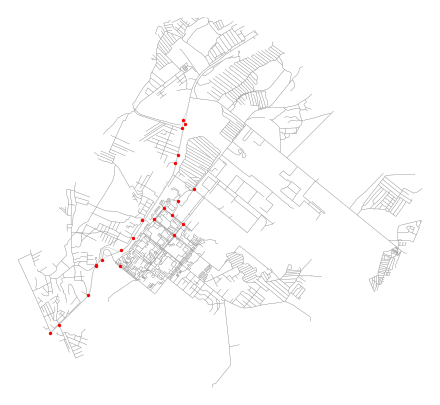

In [26]:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2, show=False)
nodes_gdf.loc[optimums_list].plot(ax=ax, c='r', markersize=2)
plt.show()

### Расчет рельефа

In [16]:
import time
from genesis.tools import get_all_neighbor_nodes


class BestNodeHillClimbing(BestPointsBase):
    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 appr_val: float = 0.95,
                 all_neighbors: bool=True,
                 node_calc_end_function:callable=None,
                 **kwargs) -> None:

        if appr_val > 1 or appr_val<0:
            raise ValueError(f'Аргумент `appr_val` должен находиться в диапазоне (0, 1)!'
                             f'Сейчас {appr_val}')
        self.appr_val = appr_val
        self.all_neighbors=all_neighbors
        self.node_calc_end_function = node_calc_end_function
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self,
                 env:nx.MultiDiGraph,
                 start_node:int,
                 tops_dict:dict,
                 area:pd.Series=None,
                 debug_route:bool=True,
                 **kwargs):
        
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип переменной `env` должен быть MultiDiGraph!")
        
        # Проверка на то что из стартового узла уже был рассчитан путь к вершине:
        if start_node in tops_dict.values():
            route = {start_node: None}
            return tops_dict[start_node], None, {}

        node_metric_func = NodeMetric(self.state_function, self.metric_function, self.appr_val, err_val=None, **kwargs)

        nodes_metric = {}
        route={}


        # Использование переданного стартового узла
        if not isinstance(start_node,int):
            raise TypeError('Тип данных start_node должен быть только int!')

        node_metric = node_metric_func(env=env, node=start_node, area=area, **kwargs)

        if node_metric is None:
            if not area is None:
                # raise ValueError(f'Достичь области `area` из стартового узла {start_node}' \
                #                  'невозможно,')
                # ВАЖНО! будет произведена оценка оценка метрики для подграфа зоны обслуживания подразделения
                node_metric = node_metric_func(env=env, node=start_node, **kwargs)
            else:
                raise ValueError('Указанный стартовый узел неприемлем, в связи с его слабой ' \
                    'связностью с остальной частью графа')
        

        nodes_metric[start_node] = node_metric

        route[start_node] = node_metric
        # logging.debug('ПЕРВЫЙ УЗЕЛ {}, метрика {}'.format(start_node, node_metric))

        # Пошаговый поиск лучшего узла от start_node
        best_metric = node_metric
        best_node = start_node
        tmp_node=None
        while best_node!=tmp_node:
            tmp_node = best_node

            if self.all_neighbors:
                nnodes = get_all_neighbor_nodes(env, tmp_node)
            else:
                nnodes = env[tmp_node]

            for node in nnodes:
                if node in nodes_metric:
                    node_metric = nodes_metric[node]
                else:
                    node_metric = node_metric_func(env=env, node=node, area=area, **kwargs)
                    nodes_metric[node] = node_metric

                # Если метрики одинаковы, в данном случае - ситуация неприемлемая и должна быть исключена.
                if best_metric!=node_metric and \
                        self.metric_function.compare(best_metric, node_metric) == node_metric:
                    best_node = node
                    best_metric = node_metric

                    # Проверка на то что из узла уже был рассчитан путь к вершине:
                    if best_node in tops_dict.values():
                        route[best_node] = best_metric
                        return tops_dict[best_node], None, route


            route[best_node] = best_metric

            # выполняем функцию завершения расчета для узла
            if self.node_calc_end_function:
                self.node_calc_end_function(best_node=best_node, best_metric=best_metric)

        if not debug_route:
            return best_node, best_metric
        else:
            return best_node, best_metric, route

def calc_relief(G, tb=None):

    print('Узлов:', G.number_of_nodes())

    bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), ArrivalTime())
    # pb = Progressbar(G.number_of_nodes(), bins=40)

    # Словарь вершин к которым ведут пути из узлов G
    # key - узел
    # value - вершина
    if tb is None:
        tops = {}
    else:
        tops=tb

    i=1
    # for start_node in list(G.nodes())[:100]:
    for start_node in list(G.nodes()):
        try:
            best_node, best_metric, route = bnhc(G, start_node, tops_dict=tops)
        except ValueError:
            print(f'Узел {start_node} слабосвязан с остальным графом')
            best_node, best_metric, route = 0, None, {}
        for route_node in route.keys():
            tops[route_node] = best_node
        unique_values = set(tops.values())
        print(f'{i:<5}', len(tops), len(unique_values), end='\r')
        if i%100==0:
            print('')
        i+=1
        # pb()
            
    return tops

ts = time.time()
# Для упрощенного графа
tops = calc_relief(Gs)
# Для неупрощенного графа
# tops = calc_relief(G, tb=tops_backup)
print(f'Время выполнения: {time.time() - ts:.2f} сек.')

Узлов: 1941
100   298 6
200   412 6
300   499 7
400   594 8
500   701 8
600   790 8
700   909 8
800   998 8
900   1095 8
Узел 2517534521 слабосвязан с остальным графом
Узел 2517534589 слабосвязан с остальным графом
1000  1210 8
1100  1294 8
Узел 3981463578 слабосвязан с остальным графом
Узел 3981463586 слабосвязан с остальным графом
1200  1382 8
1300  1475 9
1400  1543 9
Узел 5574211404 слабосвязан с остальным графом
1500  1618 9
1600  1691 9
1700  1765 9
1800  1829 9
1900  1914 9
Время выполнения: 2416.29 сек.


[426923808, 1297042721, 1705509859, 1550153892, 2586140869, 2546773068, 4702619724, 426923835, 426923837]
9


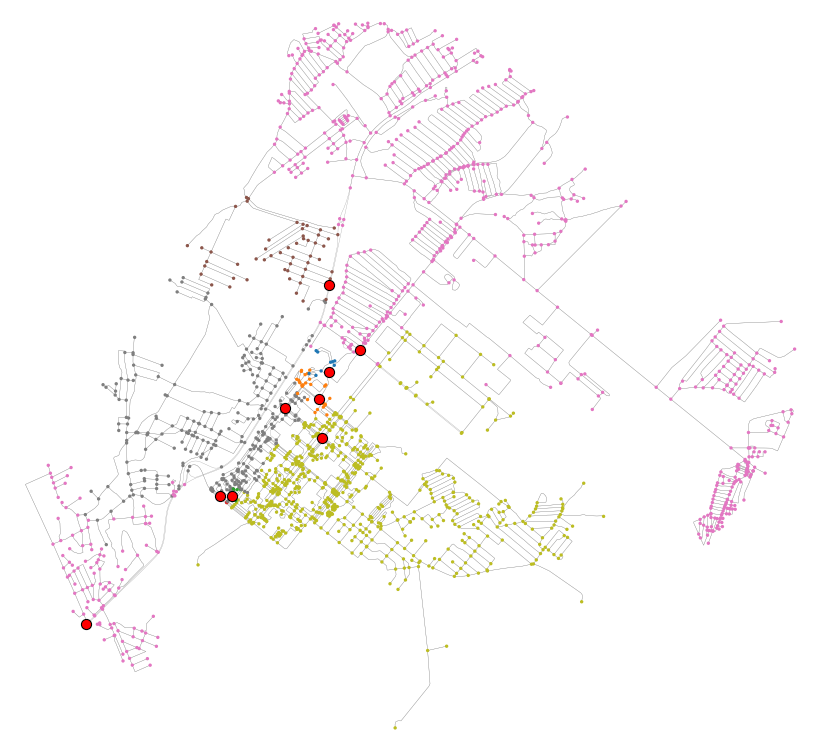

In [17]:
# Подсчет уникальных вершин
unique_values = list(set(tops.values()))
print(unique_values)
print(len(unique_values))

# Сопоставление узлов графа с теми вершинами в которые из них можно попасть
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf['tops'] = tops
nodes_gdf = nodes_gdf[nodes_gdf['tops'].notna()]
nodes_gdf['tops'] = nodes_gdf['tops'].astype(str)

# Печать карты
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ox.plot_graph(Gs, ax=ax, node_size=0, edge_linewidth=0.2, show=False)
nodes_gdf.plot(ax=ax, markersize=2, column='tops')  #, legend=True)
nodes_gdf.loc[unique_values].plot(ax=ax, c='k', markersize=50)
nodes_gdf.loc[unique_values].plot(ax=ax, c='r', markersize=30)

plt.tight_layout(pad=0)
plt.savefig('relief_Gs.png', dpi=300)
# plt.savefig('relief_G.png', dpi=300)
plt.show()

In [71]:
tops_backup = tops.copy()

### Для метрики maxtime

In [7]:
import time
from genesis.tools import get_all_neighbor_nodes


class BestNodeHillClimbing(BestPointsBase):
    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 appr_val: float = 0.95,
                 all_neighbors: bool=True,
                 node_calc_end_function:callable=None,
                 **kwargs) -> None:

        if appr_val > 1 or appr_val<0:
            raise ValueError(f'Аргумент `appr_val` должен находиться в диапазоне (0, 1)!'
                             f'Сейчас {appr_val}')
        self.appr_val = appr_val
        self.all_neighbors=all_neighbors
        self.node_calc_end_function = node_calc_end_function
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self,
                 env:nx.MultiDiGraph,
                 start_node:int,
                 tops_dict:dict,
                 area:pd.Series=None,
                 debug_route:bool=True,
                 **kwargs):
        
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип переменной `env` должен быть MultiDiGraph!")
        
        # Проверка на то что из стартового узла уже был рассчитан путь к вершине:
        if start_node in tops_dict.values():
            route = {start_node: None}
            return tops_dict[start_node], None, {}

        node_metric_func = NodeMetric(self.state_function, self.metric_function, self.appr_val, err_val=None, **kwargs)

        nodes_metric = {}
        route={}


        # Использование переданного стартового узла
        if not isinstance(start_node,int):
            raise TypeError('Тип данных start_node должен быть только int!')

        node_metric = node_metric_func(env=env, node=start_node, area=area, **kwargs)

        if node_metric is None:
            if not area is None:
                # raise ValueError(f'Достичь области `area` из стартового узла {start_node}' \
                #                  'невозможно,')
                # ВАЖНО! будет произведена оценка оценка метрики для подграфа зоны обслуживания подразделения
                node_metric = node_metric_func(env=env, node=start_node, **kwargs)
            else:
                raise ValueError('Указанный стартовый узел неприемлем, в связи с его слабой ' \
                    'связностью с остальной частью графа')
        

        nodes_metric[start_node] = node_metric

        route[start_node] = node_metric
        # logging.debug('ПЕРВЫЙ УЗЕЛ {}, метрика {}'.format(start_node, node_metric))

        # Пошаговый поиск лучшего узла от start_node
        best_metric = node_metric
        best_node = start_node
        tmp_node=None
        while best_node!=tmp_node:
            tmp_node = best_node

            if self.all_neighbors:
                nnodes = get_all_neighbor_nodes(env, tmp_node)
            else:
                nnodes = env[tmp_node]

            for node in nnodes:
                if node in nodes_metric:
                    node_metric = nodes_metric[node]
                else:
                    node_metric = node_metric_func(env=env, node=node, area=area, **kwargs)
                    nodes_metric[node] = node_metric

                # Если метрики одинаковы, в данном случае - ситуация неприемлемая и должна быть исключена.
                if best_metric!=node_metric and \
                        self.metric_function.compare(best_metric, node_metric) == node_metric:
                    best_node = node
                    best_metric = node_metric

                    # Проверка на то что из узла уже был рассчитан путь к вершине:
                    if best_node in tops_dict.values():
                        route[best_node] = best_metric
                        return tops_dict[best_node], None, route


            route[best_node] = best_metric

            # выполняем функцию завершения расчета для узла
            if self.node_calc_end_function:
                self.node_calc_end_function(best_node=best_node, best_metric=best_metric)

        if not debug_route:
            return best_node, best_metric
        else:
            return best_node, best_metric, route

def calc_relief(G, tb=None):

    print('Узлов:', G.number_of_nodes())

    bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), ArrivalTime(np.max))
    # pb = Progressbar(G.number_of_nodes(), bins=40)

    # Словарь вершин к которым ведут пути из узлов G
    # key - узел
    # value - вершина
    if tb is None:
        tops = {}
    else:
        tops=tb

    i=1
    # for start_node in list(G.nodes())[:100]:
    for start_node in list(G.nodes()):
        try:
            best_node, best_metric, route = bnhc(G, start_node, tops_dict=tops)
        except ValueError:
            print(f'Узел {start_node} слабосвязан с остальным графом')
            best_node, best_metric, route = 0, None, {}
        for route_node in route.keys():
            tops[route_node] = best_node
        unique_values = set(tops.values())
        print(f'{i:<5}', len(tops), len(unique_values), end='\r')
        if i%100==0:
            print('')
        i+=1
        # pb()
            
    return tops

ts = time.time()
# Для упрощенного графа
tops = calc_relief(Gs)
# Для неупрощенного графа
# tops = calc_relief(G, tb=tops_backup)
print(f'Время выполнения: {time.time() - ts:.2f} сек.')

Узлов: 1941
100   321 3
200   419 3
300   520 3
400   624 3
500   717 4
600   805 4
700   924 4
800   1013 4
900   1111 4
Узел 2517534521 слабосвязан с остальным графом
Узел 2517534589 слабосвязан с остальным графом
1000  1233 4
1100  1322 4
Узел 3981463578 слабосвязан с остальным графом
Узел 3981463586 слабосвязан с остальным графом
1200  1402 4
1300  1490 4
1400  1557 4
Узел 5574211404 слабосвязан с остальным графом
1500  1632 4
1600  1706 4
1700  1775 4
1800  1838 4
1900  1914 4
Время выполнения: 2623.48 сек.


[2034402008, 4329379210, 4116049991, 2034401823]
4


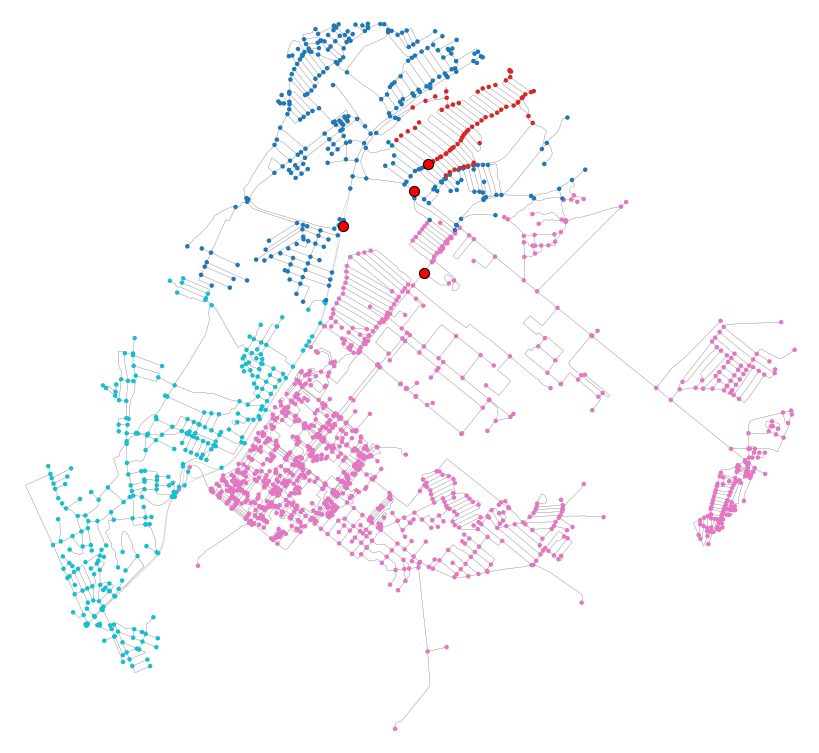

In [15]:
# Подсчет уникальных вершин
unique_values = list(set(tops.values()))
print(unique_values)
print(len(unique_values))

# Сопоставление узлов графа с теми вершинами в которые из них можно попасть
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf['tops'] = tops
nodes_gdf = nodes_gdf[nodes_gdf['tops'].notna()]
nodes_gdf['tops'] = nodes_gdf['tops'].astype(str)

# Печать карты
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ox.plot_graph(Gs, ax=ax, node_size=0, edge_linewidth=0.2, show=False)
nodes_gdf.plot(ax=ax, markersize=5, column='tops')  #, legend=True)
nodes_gdf.loc[unique_values].plot(ax=ax, c='k', markersize=50)
nodes_gdf.loc[unique_values].plot(ax=ax, c='r', markersize=30)

plt.tight_layout(pad=0)
plt.savefig('relief_max_Gs.png', dpi=300)
# plt.savefig('relief_max_G.png', dpi=300)
plt.show()